In [1]:
import sys
from pathlib import Path

# Anchor every path on the repo root regardless of where the notebook is launched
# from (repo root, src/, or src/data_analysis/). See shared_paths for the why.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
P.bootstrap()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- project plotting style ------------------------------------------------------
# The palette, font sizes and output directory live in universal_settings.yml at the
# repo root (section style.notebooks.03_academic_impact) so every notebook draws from
# one file. load_style merges the shared `base` with this notebook's overrides,
# registers the result for savefig()/extended_palette() and pushes it into rcParams.
from utils.shared_style import apply_style, extended_palette, load_style, savefig, use_style
STYLE = load_style("03_academic_impact")

print("palette:", STYLE["colors"])
print("figures ->", STYLE["savedir"], f"(save={STYLE['save']})")

palette: ['#B80C09', '#D4AF37', '#6E8B3D', '#345995']
figures -> output/figures/data_analysis/03_academic_impact (save=False)


In [8]:
# =============================================================================
# ANALYSIS PARAMETERS  --  edit these
# =============================================================================
# WHICH CLASSIFICATION SYSTEM ------------------------------------------------
# The whole notebook runs on one system; nothing below this cell is system-specific.
#   "for"  = ANZSRC 2020 Fields of Research  (hierarchical: L2 division / L4 field)
#   "rcdc" = NIH Research, Condition and Disease Categories (flat, single level "L1")
# Both arms were produced by the same count job, so their tables have identical
# columns and everything downstream is written in terms of `level` / `code`:
#   src/utils/data_analysis_03_academic_impact_field_counts.py --category for|rcdc
COL_TYPE = "rcdc"

# FOR only — which level to compare on:
#   "L4" = fine field  (e.g. 4202 Epidemiology)
#   "L2" = broad division (e.g. 42 Health Sciences)
# RCDC is flat, so it always uses its single level.
FOR_LEVEL = "L4"

# The year UK Biobank publications begin in earnest (2013 has only a handful).
# Every "before vs after" split below hinges on this line.
UKBB_YEAR = 2014

# How many of UK Biobank's OWN top categories to follow through the whole database.
TOP_N = 8

# Counting metric:
#   "n_papers" = a paper counts once in EVERY category it carries (absolute; a
#                multi-category paper is double-counted across categories)
#   "n_frac"   = its weight split evenly across its categories (per-level fractional)
# See the count job for the exact semantics.
WEIGHT = "n_papers"

# Analysis window. 2026 is dropped on purpose: the Dimensions index is still filling
# in for it, so its counts are not comparable and would fake a collapse. Raise
# YEAR_MAX once the index has caught up.
YEAR_MIN = 2004
YEAR_MAX = 2024

BEFORE_WIN = (YEAR_MIN, UKBB_YEAR - 1)   # marginal-growth window before UK Biobank
AFTER_WIN  = (UKBB_YEAR, YEAR_MAX)       # marginal-growth window after

# LABEL QUALITY GUARD ---------------------------------------------------------
# Some corpus files hand the flat-category parser an entry with an EMPTY name, which
# lands in the counts as a code of "". Those rows are not a category, so they are
# dropped — but a year where most of the background arm is blank has no usable
# whole-database denominator either, and any share computed from it is meaningless.
# A year is treated as unusable when more than BLANK_MAX of the background arm's
# tagged papers came back blank; with MASK_BAD_DENOM those years are excluded from
# the whole-database series rather than silently plotted.
BLANK_MAX = 0.05
MASK_BAD_DENOM = True

# WHERE THE PARTIALS LIVE ------------------------------------------------------
# One output directory holds every category's partials, because the count job names
# them per-category (counts.rcdc.background.shard00003.parquet, ...). The FOR arm
# predates the --category flag, so its filenames carry no category token; each arm
# lists its patterns most-specific first and the first pattern that matches wins.
COUNTS_DIR = P.FOR_COUNTS

CATEGORY_SPECS = {
    "for": {
        "label": "Fields of Research (ANZSRC 2020)",
        "unit": "field",
        "level": FOR_LEVEL,
        "patterns": {"ukbb": ("counts.for.ukbb*.parquet", "counts.ukbb*.parquet"),
                     "background": ("counts.for.background*.parquet",
                                    "counts.background*.parquet")},
    },
    "rcdc": {
        "label": "NIH Research, Condition and Disease Categories",
        "unit": "topic",
        "level": "L1",
        "patterns": {"ukbb": ("counts.rcdc.ukbb*.parquet",),
                     "background": ("counts.rcdc.background*.parquet",)},
    },
}
CAT = CATEGORY_SPECS[COL_TYPE]
LEVEL, SYSTEM, UNIT = CAT["level"], CAT["label"], CAT["unit"]

print(f"category={COL_TYPE} ({SYSTEM})")
print(f"level={LEVEL}  weight={WEIGHT}  top-N={TOP_N}  UKBB year={UKBB_YEAR}")
print(f"window {YEAR_MIN}-{YEAR_MAX}   before={BEFORE_WIN}  after={AFTER_WIN}")

category=rcdc (NIH Research, Condition and Disease Categories)
level=L1  weight=n_papers  top-N=8  UKBB year=2014
window 2004-2024   before=(2004, 2013)  after=(2014, 2024)


In [9]:
# =============================================================================
# LOAD THE TWO ARMS AND BUILD THE "WHOLE DATABASE"
# =============================================================================
# The count job stored two arms per category:
#   counts.<cat>.ukbb        = UK Biobank papers only
#   counts.<cat>.background  = the rest of Dimensions, UK Biobank papers EXCLUDED
# so the whole database is simply their sum. The background arm is one merged file
# for FOR and a five-way Slurm shard for RCDC; both are handled by globbing. We
# collapse the `type` split (article / preprint / ...) and keep the analysis window.
VALUE = WEIGHT

def _arm_files(arm):
    """Partials for one arm: the first filename pattern that matches anything."""
    for pattern in CAT["patterns"][arm]:
        hits = sorted(COUNTS_DIR.glob(pattern))
        if hits:
            return hits
    raise FileNotFoundError(f"no {COL_TYPE} '{arm}' partials in {COUNTS_DIR} "
                            f"(looked for {', '.join(CAT['patterns'][arm])})")

def _load_arm(arm):
    """(counts, label-quality) for one arm. Blank-named categories are dropped here
    and reported back so the guard in the next block can act on them."""
    files = _arm_files(arm)
    raw = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    raw = raw[(raw.level == LEVEL) & raw.year.between(YEAR_MIN, YEAR_MAX)].copy()
    raw["code"] = raw.code.fillna("").str.strip()
    blank = raw.code == ""

    counts = (raw[~blank].groupby(["year", "code", "for_label"], as_index=False)
              [["n_papers", "n_frac"]].sum())
    quality = pd.DataFrame({"tagged": raw.groupby("year").n_papers.sum(),
                            "blank": raw[blank].groupby("year").n_papers.sum()})
    quality = quality.fillna({"blank": 0.0})
    quality["blank_share"] = quality.blank / quality.tagged.where(quality.tagged > 0)
    print(f"  {arm:<10s} {len(files)} partial(s), {len(counts):,} rows, "
          f"{counts.code.nunique():,} {UNIT}s, "
          f"blank labels {quality.blank.sum() / max(quality.tagged.sum(), 1):.1%}")
    return counts, quality

print(f"loading {COL_TYPE} partials from {COUNTS_DIR}")
ukbb, q_ukbb = _load_arm("ukbb")
background, q_background = _load_arm("background")

# -- which years have a whole-database denominator worth dividing by ---------------
usable = q_background.blank_share.fillna(1.0) <= BLANK_MAX
GOOD_YEARS = [y for y in range(YEAR_MIN, YEAR_MAX + 1) if bool(usable.get(y, False))]
BAD_YEARS  = [y for y in range(YEAR_MIN, YEAR_MAX + 1) if y not in GOOD_YEARS]
DENOM_OK    = not BAD_YEARS
WHOLE_DB_OK = len(GOOD_YEARS) >= 3            # too few years to draw a trend
DENOM_NOTE  = "" if DENOM_OK else f"  —  denominator unusable in {len(BAD_YEARS)} year(s)"
WHOLE_DB_MSG = (f"no usable whole-database denominator for '{COL_TYPE}'\n"
                "the background arm's labels are blank — see the check above")

if not DENOM_OK:
    worst = q_background.blank_share.reindex(BAD_YEARS)
    print(f"\n!! BACKGROUND LABELS ARE BLANK IN {len(BAD_YEARS)} OF "
          f"{YEAR_MAX - YEAR_MIN + 1} YEARS ({BAD_YEARS[0]}-{BAD_YEARS[-1]})")
    print(f"   {worst.min():.0%}-{worst.max():.0%} of the background arm's tagged papers "
          f"come back with an empty\n   '{COL_TYPE}' name in those years, so the "
          f"whole-database counts are far too low and every\n   share derived from them "
          f"is meaningless. The fix is upstream — flat-category parsing\n   in "
          f"src/utils/data_analysis_03_academic_impact_field_counts.py, then a re-run of\n"
          f"   the background arm; the UK Biobank arm itself is unaffected.")
    print(f"   Those years are {'MASKED OUT' if MASK_BAD_DENOM else 'STILL PLOTTED'} "
          f"below (MASK_BAD_DENOM={MASK_BAD_DENOM}).")
    print(f"   Usable years: {GOOD_YEARS if GOOD_YEARS else 'none'}\n")

def flag_denominator(target):
    """Stamp a figure/axes that has no whole-database series left to draw."""
    if WHOLE_DB_OK:
        return
    kwargs = dict(ha="center", va="center", fontsize=STYLE["label_fs"],
                  color=STYLE["colors"][0],
                  bbox=dict(boxstyle="round", fc="white", ec=STYLE["colors"][0]))
    if hasattr(target, "transAxes"):          # an Axes
        target.text(0.5, 0.5, WHOLE_DB_MSG, transform=target.transAxes, **kwargs)
    else:                                     # a Figure
        target.text(0.5, 0.5, WHOLE_DB_MSG, **kwargs)

# -- the whole database = both arms summed -----------------------------------------
whole = (pd.concat([ukbb, background])
         .groupby(["year", "code", "for_label"], as_index=False)[["n_papers", "n_frac"]].sum())
if MASK_BAD_DENOM:
    whole = whole[whole.year.isin(GOOD_YEARS)]

# UK Biobank's own top categories, ranked over the after-window where it has mass.
# Ranked on the UK Biobank arm alone, so the masking above never touches this list.
_rank = (ukbb[ukbb.year >= UKBB_YEAR]
         .groupby(["code", "for_label"])[VALUE].sum()
         .sort_values(ascending=False).head(TOP_N))
TOP_CODES = [code for code, _ in _rank.index]
TOP_LABELS = [lab for _, lab in _rank.index]

# One fixed colour per category, reused in every chart: colour follows the category,
# never its rank within a given plot.
FIELD_COLORS = dict(zip(TOP_LABELS, extended_palette(TOP_N)))

def _pivot(frame, value):
    return (frame[frame.code.isin(TOP_CODES)]
            .pivot_table(index="year", columns="for_label", values=value, aggfunc="sum")
            .reindex(columns=TOP_LABELS))

whole_ts = _pivot(whole, VALUE)                     # whole-database counts, year x category
ukbb_ts  = _pivot(ukbb,  VALUE)                     # UK Biobank counts,     year x category
share_ts = (ukbb_ts.reindex(whole_ts.index) / whole_ts * 100).clip(lower=0)

def share_at(label, year=YEAR_MAX):
    """UK Biobank's share of one category in one year; NaN when that year is masked."""
    if year not in share_ts.index or label not in share_ts.columns:
        return float("nan")
    return float(share_ts.loc[year, label])

def pct(value, nd=1):
    return "n/a" if not np.isfinite(value) else f"{value:.{nd}f}%"

print(f"UK Biobank top {TOP_N} {SYSTEM} {UNIT}s ({LEVEL}, by {VALUE}, {UKBB_YEAR}+):\n")
for lab in TOP_LABELS:
    tot = int(ukbb[ukbb.for_label == lab][VALUE].sum())
    print(f"  {lab:45s} UKBB total {tot:>7,}   share@{YEAR_MAX} {pct(share_at(lab), 2):>7s}")

loading rcdc partials from /Users/valler/Python/RA/20_years_of_ukb/data/analysis/academic_impact/for_counts_out
  ukbb       1 partial(s), 1,760 rows, 263 topics, blank labels 0.0%
  background 5 partial(s), 6,573 rows, 324 topics, blank labels 0.0%
UK Biobank top 8 NIH Research, Condition and Disease Categories topics (L1, by n_papers, 2014+):

  Genetics                                      UKBB total   9,757   share@2024   1.04%
  Prevention                                    UKBB total   8,600   share@2024   0.89%
  Human Genome                                  UKBB total   7,269   share@2024   2.36%
  Clinical Research                             UKBB total   5,208   share@2024   0.24%
  Aging                                         UKBB total   4,876   share@2024   0.90%
  Brain Disorders                               UKBB total   4,604   share@2024   0.54%
  Neurosciences                                 UKBB total   4,236   share@2024   0.44%
  Cardiovascular                    

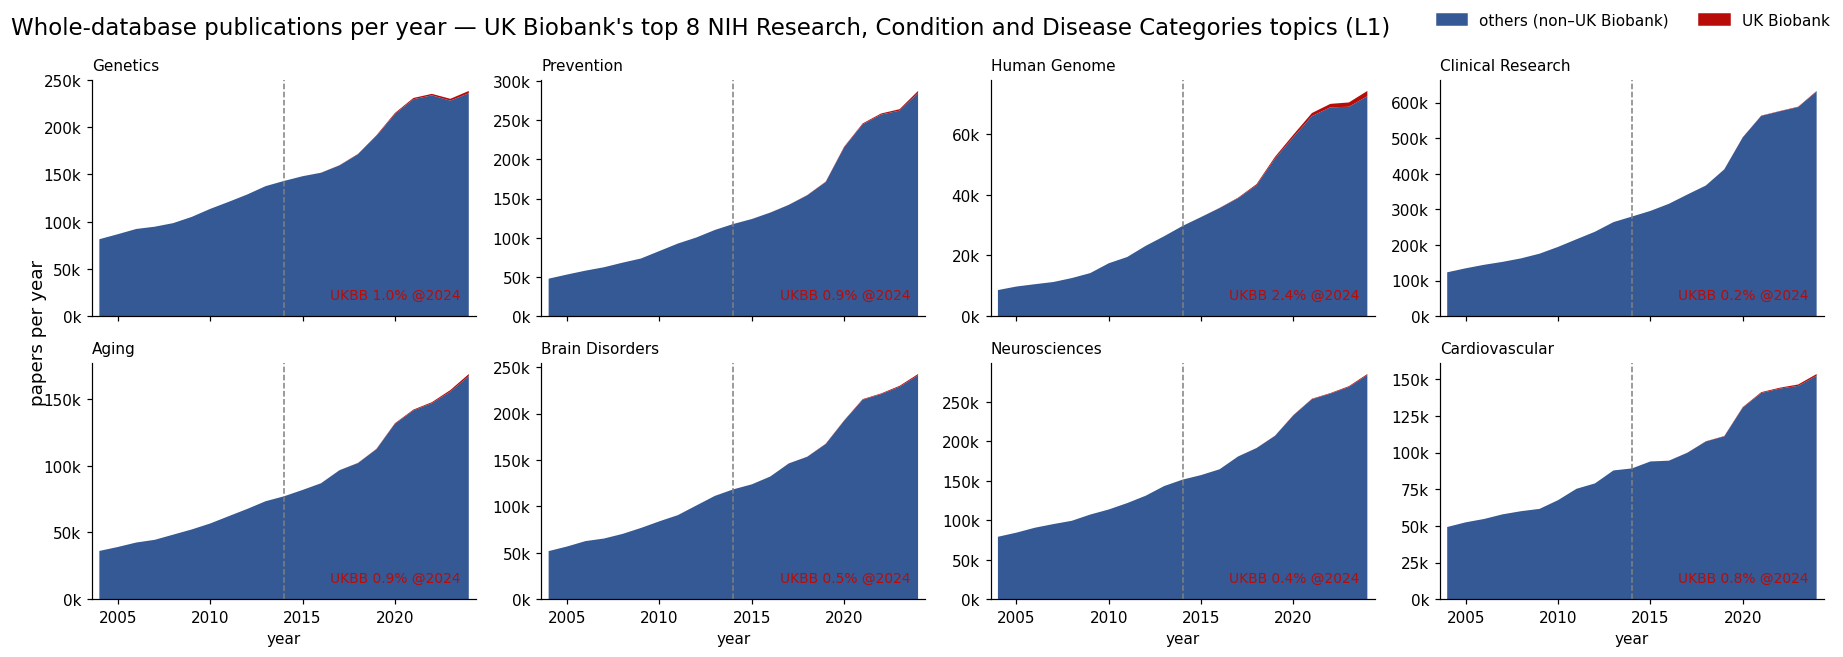

In [10]:
# =============================================================================
# CHART 1 — whole-database growth in UK Biobank's top categories: UKBB vs others
# =============================================================================
# Small multiples, one panel per category. Each panel stacks the category's yearly
# papers into "UK Biobank" vs "everyone else", so you read BOTH the overall trend
# (top of the stack = the whole database) and UK Biobank's slice within it. That
# slice is small in absolute terms, so each panel is annotated with UK Biobank's
# share in the final year. The dashed line marks the first UK Biobank year — a
# time reference, not a claimed cause.
from matplotlib.patches import Patch

C_UKBB = STYLE["colors"][0]     # red  = UK Biobank
C_REST = STYLE["colors"][3]     # blue = everyone else
kfmt = mticker.FuncFormatter(lambda x, _: f"{x / 1000:,.0f}k")   # 25371 -> "25k"

ncol = 4
nrow = int(np.ceil(TOP_N / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.0 * nrow), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, lab in zip(axes, TOP_LABELS):
    yrs = whole_ts.index.values
    ukb = ukbb_ts[lab].reindex(whole_ts.index).fillna(0.0).values
    rest = whole_ts[lab].values - ukb
    ax.stackplot(yrs, rest, ukb, colors=[C_REST, C_UKBB])
    ax.axvline(UKBB_YEAR, color=STYLE["edgecolor"], ls="--", lw=1)
    ax.set_title(lab, fontsize=STYLE["annot_fs"] + 1, loc="left")
    ax.yaxis.set_major_formatter(kfmt)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.set_ylim(bottom=0)
    ax.margins(x=0.02)
    ax.annotate(f"UKBB {pct(share_at(lab))} @{YEAR_MAX}",
                xy=(0.96, 0.06), xycoords="axes fraction", ha="right", va="bottom",
                fontsize=STYLE["annot_fs"], color=C_UKBB)
for ax in axes[TOP_N:]:
    ax.set_visible(False)
for ax in axes[TOP_N - ncol:TOP_N]:      # x-label only on the bottom row that exists
    ax.set_xlabel("year", fontsize=STYLE["tick_fs"])

fig.legend(handles=[Patch(color=C_REST, label="others (non–UK Biobank)"),
                    Patch(color=C_UKBB, label="UK Biobank")],
           loc="upper right", ncol=2, frameon=False, fontsize=STYLE["legend_fs"])
fig.suptitle(f"Whole-database publications per year — UK Biobank's top {TOP_N} "
             f"{SYSTEM} {UNIT}s ({LEVEL}){DENOM_NOTE}",
             fontsize=STYLE["title_fs"], x=0.01, ha="left")
fig.supylabel("papers per year", fontsize=STYLE["label_fs"])
flag_denominator(fig)
fig.tight_layout()
savefig(fig, f"01_whole_db_trends_{COL_TYPE}_{LEVEL}")
plt.show()

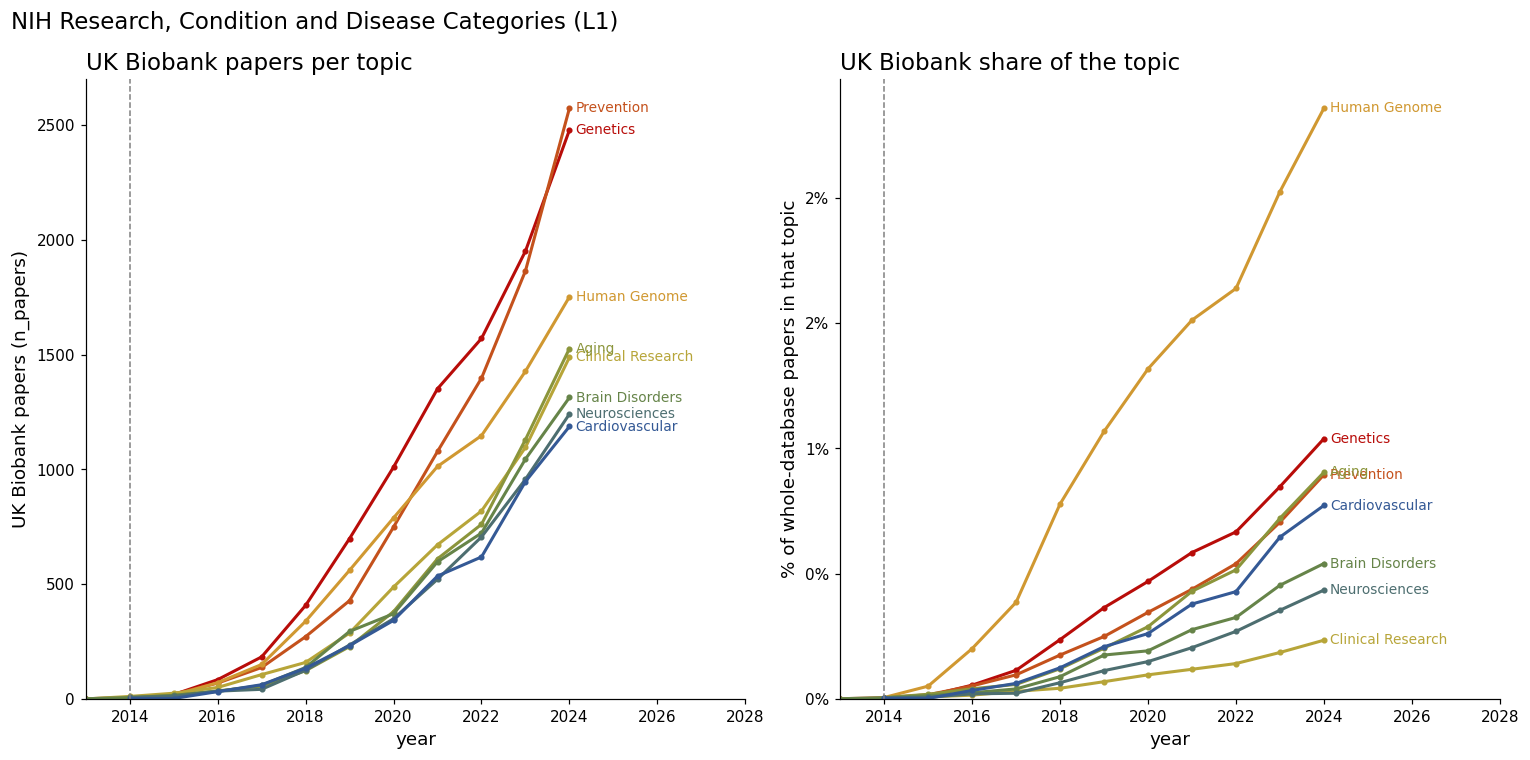

In [11]:
# =============================================================================
# CHART 2 — how much UK Biobank adds, since it started publishing
# =============================================================================
# Left  : UK Biobank's own output in each category (absolute count).
# Right : that output as a SHARE of the whole database in the same category.
# UK Biobank is a small slice of a vast literature, so the share is the truer
# measure of its footprint than the raw count. Categories are direct-labelled on
# both panels; colour follows the category across the whole notebook.
# The left panel comes from the UK Biobank arm alone, so it stays readable even
# when the background arm has no usable labels and the right panel is stamped out.
fig, (axL, axR) = plt.subplots(1, 2, figsize=STYLE["figsize_wide"])

for lab in TOP_LABELS:
    col = FIELD_COLORS[lab]
    axL.plot(ukbb_ts.index, ukbb_ts[lab], color=col, lw=2, marker="o", ms=3)
    axR.plot(share_ts.index, share_ts[lab], color=col, lw=2, marker="o", ms=3)
    yl = ukbb_ts[lab].dropna()
    if len(yl):
        axL.annotate(lab, (yl.index[-1], yl.iloc[-1]), color=col,
                     fontsize=STYLE["annot_fs"], va="center",
                     xytext=(4, 0), textcoords="offset points")
    yr = share_ts[lab].dropna()
    if len(yr):
        axR.annotate(lab, (yr.index[-1], yr.iloc[-1]), color=col,
                     fontsize=STYLE["annot_fs"], va="center",
                     xytext=(4, 0), textcoords="offset points")

for ax in (axL, axR):
    ax.axvline(UKBB_YEAR, color=STYLE["edgecolor"], ls="--", lw=1)
    ax.set_xlabel("year")
    ax.set_ylim(bottom=0)
    ax.set_xlim(UKBB_YEAR - 1, YEAR_MAX + 4)       # room for the direct labels
axL.set_title(f"UK Biobank papers per {UNIT}", loc="left", fontsize=STYLE["title_fs"])
axL.set_ylabel(f"UK Biobank papers ({VALUE})")
axR.set_title(f"UK Biobank share of the {UNIT}{DENOM_NOTE}", loc="left",
              fontsize=STYLE["title_fs"])
axR.set_ylabel(f"% of whole-database papers in that {UNIT}")
axR.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.0f}%"))
flag_denominator(axR)
fig.suptitle(f"{SYSTEM} ({LEVEL})", fontsize=STYLE["title_fs"], x=0.01, ha="left")
fig.tight_layout()
savefig(fig, f"02_ukbb_contribution_{COL_TYPE}_{LEVEL}_{WEIGHT}")
plt.show()

In [12]:
# =============================================================================
# MARGINAL ANNUAL INCREASE SPEED — before vs after UK Biobank
# =============================================================================
# "Marginal speed" = the slope (papers ADDED per year) of a straight-line fit to
# the yearly counts, measured separately in the before- and after-windows. We fit
# it on the WHOLE database (the secular trend) and, for context, on UK Biobank's
# own output.
#
# CAUTION: UK Biobank is far too small (single-digit % of any category) to bend the
# whole-database slope, so the acceleration below is a database-wide trend, NOT
# something UK Biobank caused. The ukbb_after column shows UK Biobank's own pace.
# The whole_* columns come back <NA> when the masking guard left that window empty.
def slope(frame, code, win, value=VALUE):
    y0, y1 = win
    s = (frame[(frame.code == code) & frame.year.between(y0, y1)]
         .groupby("year")[value].sum()
         .reindex(range(y0, y1 + 1)).fillna(0.0))
    if (s > 0).sum() < 2:
        return np.nan
    return float(np.polyfit(s.index.values.astype(float), s.values, 1)[0])

rows = []
for code, lab in zip(TOP_CODES, TOP_LABELS):
    wb = slope(whole, code, BEFORE_WIN)
    wa = slope(whole, code, AFTER_WIN)
    accel = wa / wb if (not np.isnan(wb) and not np.isnan(wa) and wb > 0) else np.nan
    rows.append({
        UNIT: lab,
        "whole_before_/yr": wb,
        "whole_after_/yr": wa,
        "acceleration_x": accel,
        "ukbb_after_/yr": slope(ukbb, code, AFTER_WIN),
        f"ukbb_share@{YEAR_MAX}_%": share_at(lab),
    })

speed = pd.DataFrame(rows).set_index(UNIT)
speed_fmt = speed.copy()
for c in ["whole_before_/yr", "whole_after_/yr", "ukbb_after_/yr"]:
    speed_fmt[c] = speed_fmt[c].round(0).astype("Int64")
speed_fmt["acceleration_x"] = speed_fmt["acceleration_x"].round(2)
speed_fmt[f"ukbb_share@{YEAR_MAX}_%"] = speed_fmt[f"ukbb_share@{YEAR_MAX}_%"].round(2)
speed_fmt

,whole_before_/yr,whole_after_/yr,acceleration_x,ukbb_after_/yr,ukbb_share@2024_%
topic,,,,,
Genetics,6100,11279,1.85,250,1.04
Prevention,6856,18714,2.73,241,0.89
Human Genome,1934,4991,2.58,180,2.36
Clinical Research,15067,39065,2.59,140,0.24
Aging,4081,9632,2.36,142,0.90
Brain Disorders,6349,13567,2.14,127,0.54
Neurosciences,6819,14516,2.13,119,0.44
Cardiovascular,4041,7158,1.77,115,0.77


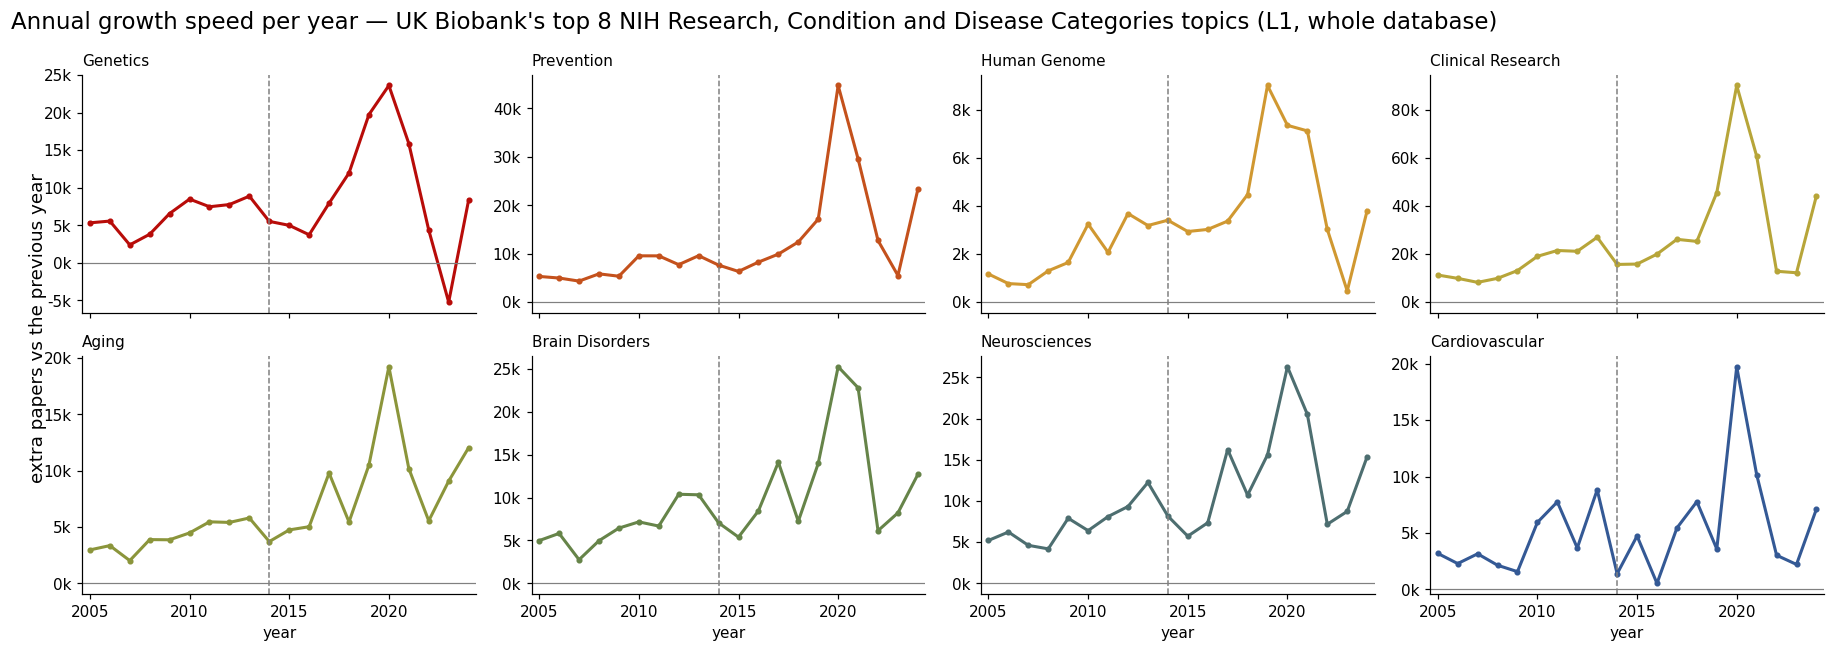

In [13]:
# =============================================================================
# CHART 3 — the growth SPEED of each category, year by year
# =============================================================================
# "Speed" = the annual increase: how many more papers a category gained versus the
# year before (the first difference of Chart 1's whole-database curve). We plot it
# ACROSS years, per category, rather than collapsing it to a single before/after
# number — so the change in pace is shown descriptively, not as a story about a
# cause. The dashed line at UKBB_YEAR is only a time reference; a rise to its
# right is a database-wide trend, and UK Biobank (single-digit % of any category)
# is far too small to have bent these curves.
speed_ts = whole_ts.diff()      # papers gained vs the previous year
kfmt = mticker.FuncFormatter(lambda x, _: f"{x / 1000:,.0f}k")

ncol = 4
nrow = int(np.ceil(TOP_N / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.0 * nrow), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, lab in zip(axes, TOP_LABELS):
    s = speed_ts[lab].dropna()
    ax.plot(s.index, s.values, color=FIELD_COLORS[lab], lw=2, marker="o", ms=3)
    ax.axhline(0, color=STYLE["edgecolor"], lw=0.8)
    ax.axvline(UKBB_YEAR, color=STYLE["edgecolor"], ls="--", lw=1)
    ax.set_title(lab, fontsize=STYLE["annot_fs"] + 1, loc="left")
    ax.yaxis.set_major_formatter(kfmt)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.margins(x=0.02)
for ax in axes[TOP_N:]:
    ax.set_visible(False)
for ax in axes[TOP_N - ncol:TOP_N]:
    ax.set_xlabel("year", fontsize=STYLE["tick_fs"])

fig.suptitle(f"Annual growth speed per year — UK Biobank's top {TOP_N} {SYSTEM} "
             f"{UNIT}s ({LEVEL}, whole database){DENOM_NOTE}",
             fontsize=STYLE["title_fs"], x=0.01, ha="left")
fig.supylabel("extra papers vs the previous year", fontsize=STYLE["label_fs"])
flag_denominator(fig)
fig.tight_layout()
savefig(fig, f"03_growth_speed_{COL_TYPE}_{LEVEL}")
plt.show()